In [4]:
import pandas as pd 
from matplotlib import pyplot as plt 

In [5]:
df = pd.read_csv("data.csv", sep=';')

In [6]:
df.head()

,Date,Starting (USD),Ending (USD)
0,01.01.24,16800,16500
1,01.12.23,15900,16100
2,01.11.23,15800,15300
3,01.10.23,16100,16200
4,01.09.23,16300,15700


In [7]:
df.isnull().sum()

Date              0
Starting (USD)    0
Ending (USD)      0
dtype: int64

In [8]:
#df.drop('Date', axis=1)
df = df.drop(columns = ['Date'])

In [9]:
df.head()

,Starting (USD),Ending (USD)
0,16800,16500
1,15900,16100
2,15800,15300
3,16100,16200
4,16300,15700


Text(0.5, 1.0, 'Stock Prices')

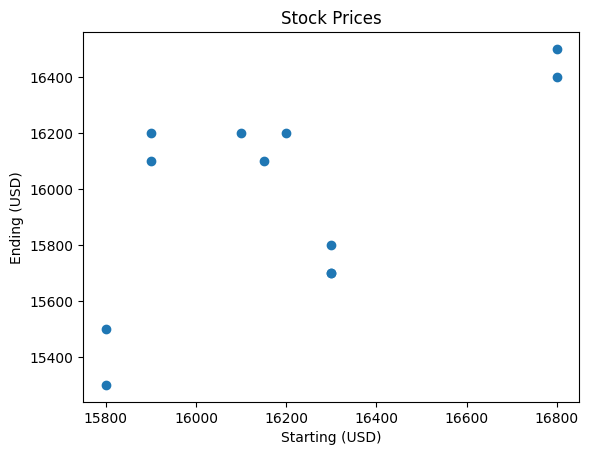

In [10]:
plt.scatter(df['Starting (USD)'] , df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Stock Prices')

In [28]:
# Features
x = df.drop(columns=['Ending (USD)'])

# Target
y = df['Ending (USD)']

In [29]:
x.head()

,Starting (USD),Pred Y
0,16800,16498.360656
1,15900,15760.655738
2,15800,15678.688525
3,16100,15924.590164
4,16300,16088.524590


In [13]:
y.head()

0    16500
1    16100
2    15300
3    16200
4    15700
Name: Ending (USD), dtype: int64

Text(0.5, 1.0, 'Stock Prices')

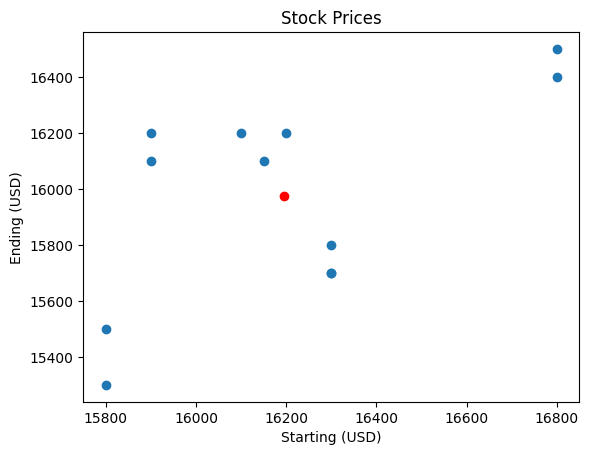

In [27]:
plt.scatter(x.mean() , y.mean(), color='red')
plt.scatter(df['Starting (USD)'] , df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Stock Prices')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
print(f'Predicted values: {y_pred}')


Predicted values: [15760.6557377  16088.52459016 16088.52459016]


In [16]:
# y = mx + c

# m is the slope
# c is the y-intercept
# x is the independent variable
# y is the dependent variable

m = model.coef_
c = model.intercept_

print(f"m = {m}")
print(f"c = {c}")

m = [0.81967213]
c = 2727.8688524590198


In [17]:
print(m * 16700 + c)

[16416.39344262]


In [20]:
df['Pred Y']=model.predict(x)
df.head()

,Starting (USD),Ending (USD),Pred Y
0,16800,16500,16498.360656
1,15900,16100,15760.655738
2,15800,15300,15678.688525
3,16100,16200,15924.590164
4,16300,15700,16088.524590
